In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import requests
try:
    print("internet OK:", requests.get("https://wwwn.cdc.gov", timeout=15).status_code)
except Exception as e:
    print("NO internet:", str(e)[:150])

internet OK: 200


In [2]:
import requests
cands = {
 "DEMO 2005-06": "https://wwwn.cdc.gov/Nchs/Nhanes/2005-2006/DEMO_D.XPT",
 "VID 2005-06 (vitamin D)": "https://wwwn.cdc.gov/Nchs/Nhanes/2005-2006/VID_D.XPT",
 "Mortality 2005-06": "https://ftp.cdc.gov/pub/Health_Statistics/NCHS/datalinkage/linked_mortality/NHANES_2005_2006_MORT_2019_PUBLIC.dat",
}
for name, u in cands.items():
    try:
        r = requests.head(u, timeout=20, allow_redirects=True)
        print(name, "->", r.status_code, r.headers.get("Content-Length"))
    except Exception as e:
        print(name, "-> ERROR", str(e)[:120])

DEMO 2005-06 -> 200 20
VID 2005-06 (vitamin D) -> 200 20
Mortality 2005-06 -> 200 506774


In [3]:
import requests
tests = {
 "DEMO old":  "https://wwwn.cdc.gov/Nchs/Nhanes/2005-2006/DEMO_D.XPT",
 "DEMO new?": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2005/DataFiles/DEMO_D.xpt",
 "VID new?":  "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2005/DataFiles/VID_D.xpt",
 "MORT":      "https://ftp.cdc.gov/pub/Health_Statistics/NCHS/datalinkage/linked_mortality/NHANES_2005_2006_MORT_2019_PUBLIC.dat",
}
for name, u in tests.items():
    try:
        r = requests.get(u, timeout=60)
        print(f"{name:10s} status {r.status_code} | bytes {len(r.content):>9,} | start: {r.content[:60]!r}")
    except Exception as e:
        print(name, "ERROR", str(e)[:100])

DEMO old   status 200 | bytes    20,905 | start: b'<!DOCTYPE html>\r\n<html lang="en-us" class="cdc-2022 theme-bl'
DEMO new?  status 200 | bytes 3,566,560 | start: b'HEADER RECORD*******LIBRARY HEADER RECORD!!!!!!!000000000000'
VID new?   status 200 | bytes   152,080 | start: b'HEADER RECORD*******LIBRARY HEADER RECORD!!!!!!!000000000000'
MORT       status 200 | bytes   506,774 | start: b'31127         2.   ..                     .  .\r\n31128       '


In [4]:
import requests, io, os, pandas as pd, numpy as np
os.makedirs("/kaggle/working/data", exist_ok=True)
BASE = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2005/DataFiles/"

def get_xpt(code):
    r = requests.get(BASE + code + ".xpt", timeout=120); r.raise_for_status()
    open(f"/kaggle/working/data/{code}.xpt", "wb").write(r.content)
    return pd.read_sas(io.BytesIO(r.content), format="xport")

demo, vid = get_xpt("DEMO_D"), get_xpt("VID_D")
print("DEMO_D", demo.shape, "| VID_D", vid.shape)
print("VID columns:", list(vid.columns))

# --- mortality: fixed-width layout from my memory of the NCHS read-in code; CHECK against the data dictionary ---
mu = "https://ftp.cdc.gov/pub/Health_Statistics/NCHS/datalinkage/linked_mortality/NHANES_2005_2006_MORT_2019_PUBLIC.dat"
raw = requests.get(mu, timeout=120).content
open("/kaggle/working/data/mort_2005_2006.dat", "wb").write(raw)
cols = [("SEQN",0,14),("ELIGSTAT",14,15),("MORTSTAT",15,16),("UCOD_LEADING",16,19),
        ("DIABETES",19,20),("HYPERTEN",20,21),("PERMTH_INT",42,45),("PERMTH_EXM",45,48)]
mort = pd.read_fwf(io.BytesIO(raw), colspecs=[(a,b) for _,a,b in cols], names=[n for n,_,_ in cols], na_values=["."])
print("\nmortality rows:", len(mort))
print(mort.head(3).to_string())
print("\nELIGSTAT counts:\n", mort.ELIGSTAT.value_counts(dropna=False).to_string())
print("MORTSTAT among eligible:\n", mort[mort.ELIGSTAT == 1].MORTSTAT.value_counts(dropna=False).to_string())

df = demo.merge(vid, on="SEQN", how="left").merge(mort, on="SEQN", how="left")
adults = df[(df.ELIGSTAT == 1)]
print("\nmerged:", df.shape, "| eligible adults:", len(adults))
print("deaths:", int(adults.MORTSTAT.sum()), "| median follow-up (months):", adults.PERMTH_EXM.median())
print("age range:", adults.RIDAGEYR.min(), "-", adults.RIDAGEYR.max())

DEMO_D (10348, 43) | VID_D (9440, 2)
VID columns: ['SEQN', 'LBDVIDMS']

mortality rows: 10348
    SEQN  ELIGSTAT  MORTSTAT  UCOD_LEADING  DIABETES  HYPERTEN  PERMTH_INT  PERMTH_EXM
0  31127         2       NaN           NaN       NaN       NaN         NaN         NaN
1  31128         2       NaN           NaN       NaN       NaN         NaN         NaN
2  31129         2       NaN           NaN       NaN       NaN         NaN         NaN

ELIGSTAT counts:
 ELIGSTAT
1    5561
2    4785
3       2
MORTSTAT among eligible:
 MORTSTAT
0.0    4534
1.0    1027

merged: (10348, 51) | eligible adults: 5561
deaths: 1027 | median follow-up (months): 165.0
age range: 18.0 - 85.0


In [5]:
print(vid.LBDVIDMS.describe().round(2).to_string())
print("missing:", int(vid.LBDVIDMS.isna().sum()), "of", len(vid))
print("share of values below 5:", round(float((vid.LBDVIDMS < 5).mean()), 3))

# candidate covariate files for 2005-06 (names from memory; checking they exist and parse)
for code in ["BMX_D", "SMQ_D", "ALQ_D", "PAQ_D"]:
    try:
        x = get_xpt(code); print(code, x.shape, list(x.columns)[:12])
    except Exception as e:
        print(code, "FAILED:", str(e)[:80])

want = ["RIDAGEYR","RIAGENDR","RIDRETH1","DMDEDUC2","INDFMPIR","RIDEXMON","SDMVPSU","SDMVSTRA","WTMEC2YR"]
print("DEMO has:", [c for c in want if c in demo.columns], "| missing:", [c for c in want if c not in demo.columns])

count    8306.00
mean       57.95
std        20.53
min        13.20
25%        42.20
50%        56.80
75%        71.30
max       195.00
missing: 1134 of 9440
share of values below 5: 0.0
BMX_D (9950, 27) ['SEQN', 'BMDSTATS', 'BMXWT', 'BMIWT', 'BMXRECUM', 'BMIRECUM', 'BMXHEAD', 'BMIHEAD', 'BMXHT', 'BMIHT', 'BMXBMI', 'BMXLEG']
SMQ_D (7186, 39) ['SEQN', 'SMQ020', 'SMD030', 'SMQ040', 'SMQ050Q', 'SMQ050U', 'SMD055', 'SMD057', 'SMD070', 'SMD075', 'SMQ077', 'SMD641']
ALQ_D (4773, 9) ['SEQN', 'ALQ101', 'ALQ110', 'ALQ120Q', 'ALQ120U', 'ALQ130', 'ALQ140Q', 'ALQ140U', 'ALQ150']
PAQ_D (9424, 20) ['SEQN', 'PAD020', 'PAQ050Q', 'PAQ050U', 'PAD080', 'PAQ100', 'PAD120', 'PAD160', 'PAQ180', 'PAD200', 'PAD320', 'PAD440']
DEMO has: ['RIDAGEYR', 'RIAGENDR', 'RIDRETH1', 'DMDEDUC2', 'INDFMPIR', 'RIDEXMON', 'SDMVPSU', 'SDMVSTRA', 'WTMEC2YR'] | missing: []


In [6]:
import requests, io, os, pandas as pd
os.makedirs("/kaggle/working/data", exist_ok=True)
cycles = {"B":2001,"C":2003,"D":2005,"E":2007,"F":2009,"G":2011,"H":2013}
def try_xpt(code, y):
    try:
        r = requests.get(f"https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/{y}/DataFiles/{code}.xpt", timeout=120)
        if r.status_code != 200 or not r.content.startswith(b"HEADER"): return None
        open(f"/kaggle/working/data/{code}.xpt", "wb").write(r.content)
        return pd.read_sas(io.BytesIO(r.content), format="xport")
    except Exception as e:
        return None
def try_mort(y):
    try:
        u = f"https://ftp.cdc.gov/pub/Health_Statistics/NCHS/datalinkage/linked_mortality/NHANES_{y}_{y+1}_MORT_2019_PUBLIC.dat"
        r = requests.get(u, timeout=120)
        return r.content if r.status_code == 200 and len(r.content) > 10000 else None
    except Exception:
        return None

store = {}
for s, y in cycles.items():
    row = {}
    for base in ["DEMO", "VID", "BMX", "SMQ"]:
        d = try_xpt(f"{base}_{s}", y)
        store[(base, s)] = d
        row[base] = None if d is None else d.shape
    m = try_mort(y); store[("MORT", s)] = m
    row["MORT_bytes"] = None if m is None else len(m)
    print(f"{y}-{str(y+1)[-2:]} ({s}):", row)
    if store[("VID", s)] is not None: print("    VID columns:", list(store[("VID", s)].columns))

2001-02 (B): {'DEMO': (11039, 37), 'VID': (8647, 2), 'BMX': (10477, 26), 'SMQ': (5411, 42), 'MORT_bytes': 540362}
    VID columns: ['SEQN', 'LBDVIDMS']
2003-04 (C): {'DEMO': (10122, 44), 'VID': (9179, 2), 'BMX': (9643, 33), 'SMQ': (5041, 42), 'MORT_bytes': 495722}
    VID columns: ['SEQN', 'LBDVIDMS']
2005-06 (D): {'DEMO': (10348, 43), 'VID': (9440, 2), 'BMX': (9950, 27), 'SMQ': (7186, 39), 'MORT_bytes': 506774}
    VID columns: ['SEQN', 'LBDVIDMS']
2007-08 (E): {'DEMO': (10149, 43), 'VID': (9307, 9), 'BMX': (9762, 23), 'SMQ': (7145, 37), 'MORT_bytes': 498376}
    VID columns: ['SEQN', 'LBXVIDMS', 'LBDVIDLC', 'LBXVD2MS', 'LBDVD2LC', 'LBXVD3MS', 'LBDVD3LC', 'LBXVE3MS', 'LBDVE3LC']
2009-10 (F): {'DEMO': (10537, 43), 'VID': (9835, 9), 'BMX': (10253, 23), 'SMQ': (7528, 37), 'MORT_bytes': 517751}
    VID columns: ['SEQN', 'LBXVIDMS', 'LBDVIDLC', 'LBXVD2MS', 'LBDVD2LC', 'LBXVD3MS', 'LBDVD3LC', 'LBXVE3MS', 'LBDVE3LC']
2011-12 (G): {'DEMO': (9756, 48), 'VID': (8956, 9), 'BMX': (9338, 26), 'SMQ

In [7]:
import pandas as pd, numpy as np, io
mcols = [("SEQN",0,14),("ELIGSTAT",14,15),("MORTSTAT",15,16),("PERMTH_INT",42,45),("PERMTH_EXM",45,48)]
parse_mort = lambda raw: pd.read_fwf(io.BytesIO(raw), colspecs=[(a,b) for _,a,b in mcols],
                                     names=[n for n,_,_ in mcols], na_values=["."])
keep_demo = ["SEQN","RIDAGEYR","RIAGENDR","RIDRETH1","DMDEDUC2","INDFMPIR","RIDEXMON","WTMEC2YR","SDMVPSU","SDMVSTRA"]
parts, notes = [], []
for s, y in cycles.items():
    demo, vid, bmx, smq = (store[(k, s)] for k in ["DEMO", "VID", "BMX", "SMQ"])
    vcol = "LBXVIDMS" if "LBXVIDMS" in vid.columns else "LBDVIDMS"
    x = (demo[[c for c in keep_demo if c in demo.columns]]
         .merge(vid[["SEQN", vcol]].rename(columns={vcol: "vitd"}), on="SEQN", how="left")
         .merge(bmx[[c for c in ["SEQN", "BMXBMI"] if c in bmx.columns]], on="SEQN", how="left")
         .merge(smq[[c for c in ["SEQN", "SMQ020", "SMQ040"] if c in smq.columns]], on="SEQN", how="left")
         .merge(parse_mort(store[("MORT", s)])[["SEQN", "ELIGSTAT", "MORTSTAT", "PERMTH_EXM"]], on="SEQN", how="left"))
    x["cycle"], x["vitd_col"] = y, vcol
    notes.append((y, [c for c in keep_demo + ["BMXBMI", "SMQ020", "SMQ040"] if c not in x.columns]))
    parts.append(x)
df = pd.concat(parts, ignore_index=True)
print("columns missing per cycle:", [n for n in notes if n[1]])

df = df[df.ELIGSTAT == 1].copy()                      # eligible adults with linked mortality
for c in ["DMDEDUC2", "SMQ020", "SMQ040"]:
    df.loc[df[c].isin([7, 9]), c] = np.nan            # refused / don't know
df["smoke"] = np.select([df.SMQ020 == 2, (df.SMQ020 == 1) & (df.SMQ040 == 3), (df.SMQ020 == 1) & df.SMQ040.isin([1, 2])],
                        ["never", "former", "current"], default="unknown")
df["died"] = df.MORTSTAT.astype(float)

g = df.groupby("cycle")
print(pd.DataFrame({"eligible": g.size(), "has_vitd": g.vitd.apply(lambda v: v.notna().sum()),
                    "deaths": g.died.sum(), "median_vitd": g.vitd.median().round(1),
                    "mean_vitd": g.vitd.mean().round(1), "median_fu_months": g.PERMTH_EXM.median()}).to_string())
print("\ncovariate missingness among adults with vitamin D:")
print(df[df.vitd.notna()][["RIDAGEYR", "RIAGENDR", "RIDRETH1", "DMDEDUC2", "INDFMPIR", "BMXBMI", "smoke"]]
      .apply(lambda c: (c.isna() | (c == "unknown")).mean()).round(3).to_string())
df.to_csv("/kaggle/working/cohort_raw.csv", index=False)
print("\nsaved", df.shape)

columns missing per cycle: []
       eligible  has_vitd  deaths  median_vitd  mean_vitd  median_fu_months
cycle                                                                      
2001       5987      5148  1624.0         56.3       57.8             212.0
2003       5610      5006  1420.0         55.7       57.8             189.0
2005       5561      5012  1027.0         54.4       56.3             165.0
2007       6219      4823  1126.0         60.0       61.3             141.0
2009       6510      5995   861.0         60.9       63.1             118.0
2011       5849      5232   628.0         60.5       63.9              94.0
2013       6100      5658   467.0         62.0       65.2              71.0

covariate missingness among adults with vitamin D:
RIDAGEYR    0.000
RIAGENDR    0.000
RIDRETH1    0.000
DMDEDUC2    0.072
INDFMPIR    0.072
BMXBMI      0.019
smoke       0.064

saved (41836, 21)


In [8]:
import statsmodels.formula.api as smf
from statsmodels.duration.hazard_regression import PHReg

d = df[df.vitd.notna()].copy()
d["low"] = (d.vitd < 50).astype(int); d["t"] = d.PERMTH_EXM
covs = ["RIDAGEYR", "RIAGENDR", "RIDRETH1", "DMDEDUC2", "INDFMPIR", "BMXBMI", "smoke", "RIDEXMON"]
d = d.dropna(subset=covs); d = d[d.smoke != "unknown"]
print("complete-case adults:", len(d), "| low vitamin D share:", d.low.mean().round(3))
print("min follow-up among survivors (months):", d[d.died == 0].t.min())

rhs = "low + RIDAGEYR + I(RIDAGEYR**2) + C(RIAGENDR) + C(RIDRETH1) + C(DMDEDUC2) + INDFMPIR + BMXBMI + C(smoke) + C(RIDEXMON) + C(cycle)"
# ---- 5-year mortality (drop people censored before 60 months) ----
d5 = d[(d.t > 60) | (d.died == 1)].copy(); d5["died5"] = ((d5.died == 1) & (d5.t <= 60)).astype(int)
print("5-year sample:", len(d5), "| 5-year deaths:", d5.died5.sum())

def effects(x):
    naive = x[x.low == 1].died5.mean() - x[x.low == 0].died5.mean()
    m = smf.logit("died5 ~ " + rhs, data=x).fit(disp=0)
    rd = m.predict(x.assign(low=1)).mean() - m.predict(x.assign(low=0)).mean()   # standardized risk difference
    return naive, rd, np.exp(m.params["low"])
naive, rd, orr = effects(d5)
rng = np.random.default_rng(0)
bs = np.array([effects(d5.sample(len(d5), replace=True, random_state=int(rng.integers(1e9)))) for _ in range(100)])
ci = lambda j: np.percentile(bs[:, j], [2.5, 97.5]).round(4)
print(f"\n5-yr mortality, low vs not low (percentage-point difference, bootstrap 95% CI):")
print(f"  naive difference         {naive*100:+.2f}  {ci(0)*100}")
print(f"  adjusted (standardized)  {rd*100:+.2f}  {ci(1)*100}")
print(f"  adjusted odds ratio      {orr:.2f}  {np.exp(np.percentile(np.log(bs[:,2]), [2.5, 97.5])).round(2)}")

# ---- Cox model stratified by cycle ----
def cox(formula):
    r = PHReg.from_formula(formula, data=d, status=d.died.values, strata=d.cycle.values).fit()
    i = r.model.exog_names.index("low"); b, se = r.params[i], r.bse[i]
    return np.exp(b), np.exp(b - 1.96 * se), np.exp(b + 1.96 * se)
hr = cox("t ~ low"); print(f"\nCox, unadjusted:  HR {hr[0]:.2f} [{hr[1]:.2f}, {hr[2]:.2f}]")
hr = cox("t ~ " + rhs.replace(" + C(cycle)", "")); print(f"Cox, adjusted:    HR {hr[0]:.2f} [{hr[1]:.2f}, {hr[2]:.2f}]")
d.to_csv("/kaggle/working/cohort_clean.csv", index=False)

complete-case adults: 31180 | low vitamin D share: 0.347
min follow-up among survivors (months): 57.0
5-year sample: 31068 | 5-year deaths: 1850

5-yr mortality, low vs not low (percentage-point difference, bootstrap 95% CI):
  naive difference         +0.69  [0.13 1.25]
  adjusted (standardized)  +2.32  [1.72 3.01]
  adjusted odds ratio      1.61  [1.44 1.85]

Cox, unadjusted:  HR 1.05 [0.99, 1.11]
Cox, adjusted:    HR 1.37 [1.29, 1.46]


In [9]:
print("mean age by low-vitamin-D status:\n", d.groupby("low").RIDAGEYR.mean().round(1).to_string())
print("\nshare low by race/ethnicity code (1=Mex-Am,2=other Hisp,3=NH white,4=NH Black,5=other):\n",
      d.groupby("RIDRETH1").low.mean().round(3).to_string())
print("\nmean BMI by low:", d.groupby("low").BMXBMI.mean().round(1).to_dict())
print("share current smoker by low:", d.assign(cs=(d.smoke == "current")).groupby("low").cs.mean().round(3).to_dict())

steps = [("age", "RIDAGEYR + I(RIDAGEYR**2)"), ("+ sex", "C(RIAGENDR)"), ("+ race/ethnicity", "C(RIDRETH1)"),
         ("+ BMI", "BMXBMI"), ("+ smoking", "C(smoke)"), ("+ education, income", "C(DMDEDUC2) + INDFMPIR"),
         ("+ exam season", "C(RIDEXMON)")]
print(f"\n{'Cox model (stratified by cycle)':32s} HR    95% CI")
h = cox("t ~ low"); print(f"{'unadjusted':32s} {h[0]:.2f}  [{h[1]:.2f}, {h[2]:.2f}]")
terms = []
for name, t in steps:
    terms.append(t); h = cox("t ~ low + " + " + ".join(terms))
    print(f"{name:32s} {h[0]:.2f}  [{h[1]:.2f}, {h[2]:.2f}]")

mean age by low-vitamin-D status:
 low
0    50.3
1    46.8

share low by race/ethnicity code (1=Mex-Am,2=other Hisp,3=NH white,4=NH Black,5=other):
 RIDRETH1
1.0    0.436
2.0    0.350
3.0    0.185
4.0    0.645
5.0    0.396

mean BMI by low: {0: 28.1, 1: 30.3}
share current smoker by low: {0: 0.198, 1: 0.249}

Cox model (stratified by cycle)  HR    95% CI
unadjusted                       1.05  [0.99, 1.11]
age                              1.40  [1.32, 1.48]
+ sex                            1.43  [1.35, 1.52]
+ race/ethnicity                 1.50  [1.41, 1.60]
+ BMI                            1.50  [1.41, 1.60]
+ smoking                        1.42  [1.34, 1.52]
+ education, income              1.38  [1.30, 1.47]
+ exam season                    1.37  [1.29, 1.46]


In [10]:
d["low30"] = (d.vitd < 30).astype(int); d["low50"] = d.low; d["low75"] = (d.vitd < 75).astype(int)
d["v10"] = -d.vitd / 10                       # HR per 10 nmol/L LOWER vitamin D
full = "RIDAGEYR + I(RIDAGEYR**2) + C(RIAGENDR) + C(RIDRETH1) + BMXBMI + C(smoke) + C(DMDEDUC2) + INDFMPIR + C(RIDEXMON)"

def run(data, expo, lag):
    x = data[data.t > lag].copy(); x["t2"] = x.t - lag
    r = PHReg.from_formula(f"t2 ~ {expo} + {full}", data=x, status=x.died.values, strata=x.cycle.values).fit()
    i = r.model.exog_names.index(expo); b, se = r.params[i], r.bse[i]
    return np.exp(b), np.exp(b - 1.96*se), np.exp(b + 1.96*se), len(x), int(x.died.sum())

rows = []
for sname, sub in [("all cycles", d), ("2001-06", d[d.cycle <= 2005]), ("2007-14", d[d.cycle >= 2007])]:
    for lag in [0, 24, 60]:
        for expo in ["low30", "low50", "low75", "v10"]:
            h = run(sub, expo, lag)
            rows.append(dict(sample=sname, lag_months=lag, exposure=expo, HR=round(h[0], 2),
                             lo=round(h[1], 2), hi=round(h[2], 2), n=h[3], deaths=h[4]))
mv = pd.DataFrame(rows); mv.to_csv("/kaggle/working/multiverse_v1.csv", index=False)
print(mv.to_string(index=False))
print("\nHR range across all specs:", mv.HR.min(), "to", mv.HR.max())

    sample  lag_months exposure   HR   lo   hi     n  deaths
all cycles           0    low30 1.66 1.51 1.83 31176    5077
all cycles           0    low50 1.37 1.29 1.46 31176    5077
all cycles           0    low75 1.19 1.11 1.27 31176    5077
all cycles           0      v10 1.06 1.05 1.08 31176    5077
all cycles          24    low30 1.61 1.45 1.79 30560    4461
all cycles          24    low50 1.33 1.24 1.42 30560    4461
all cycles          24    low75 1.18 1.10 1.27 30560    4461
all cycles          24      v10 1.06 1.04 1.08 30560    4461
all cycles          60    low30 1.65 1.46 1.86 29218    3231
all cycles          60    low50 1.28 1.18 1.39 29218    3231
all cycles          60    low75 1.19 1.09 1.29 29218    3231
all cycles          60      v10 1.06 1.04 1.08 29218    3231
   2001-06           0    low30 1.65 1.46 1.88 12489    2875
   2001-06           0    low50 1.36 1.25 1.47 12489    2875
   2001-06           0    low75 1.15 1.04 1.27 12489    2875
   2001-06           0  

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier as HGB
from sklearn.model_selection import KFold
from joblib import Parallel, delayed

base = d5.copy()
Xd = pd.get_dummies(base[["RIDAGEYR","RIAGENDR","RIDRETH1","DMDEDUC2","INDFMPIR","BMXBMI","smoke","RIDEXMON"]],
                    columns=["RIAGENDR","RIDRETH1","DMDEDUC2","smoke","RIDEXMON"], drop_first=True).astype(float)
X = ((Xd - Xd.mean()) / Xd.std()).values; cols = list(Xd.columns)
iage, ibmi = cols.index("RIDAGEYR"), cols.index("BMXBMI")
A_real, Y_real = base.low.values.astype(int), base.died5.values.astype(int)
sig = lambda z: 1 / (1 + np.exp(-z))
pa = LogisticRegression(C=1e6, max_iter=2000).fit(X, A_real); lp_a = X @ pa.coef_[0] + pa.intercept_[0]
py = LogisticRegression(C=1e6, max_iter=2000).fit(np.column_stack([X, A_real]), Y_real)
g_lin = X @ py.coef_[0][:-1] + py.intercept_[0]
print("real data: P(low) =", A_real.mean().round(3), "| P(5-yr death) =", Y_real.mean().round(3), "| covariates:", X.shape[1])

def est_all(Xr, A, Y, seed):
    n = len(Y); out = {}
    out["naive"] = Y[A == 1].mean() - Y[A == 0].mean()
    m = LogisticRegression(C=1e6, max_iter=2000).fit(np.column_stack([Xr, A]), Y)
    mu1 = m.predict_proba(np.column_stack([Xr, np.ones(n)]))[:, 1]; mu0 = m.predict_proba(np.column_stack([Xr, np.zeros(n)]))[:, 1]
    out["regression"] = (mu1 - mu0).mean()
    e = np.clip(LogisticRegression(C=1e6, max_iter=2000).fit(Xr, A).predict_proba(Xr)[:, 1], .01, .99)
    out["ipw"] = (A*Y/e).sum() / (A/e).sum() - ((1-A)*Y/(1-e)).sum() / ((1-A)/(1-e)).sum()
    psi = mu1 - mu0 + A*(Y-mu1)/e - (1-A)*(Y-mu0)/(1-e)
    out["aipw_logit"], out["se_aipw_logit"] = psi.mean(), psi.std() / np.sqrt(n)
    eg, m1, m0 = np.zeros(n), np.zeros(n), np.zeros(n)
    mk = lambda: HGB(max_iter=100, learning_rate=0.1, max_depth=3, min_samples_leaf=40)
    for tr, te in KFold(2, shuffle=True, random_state=seed).split(Xr):
        eg[te] = mk().fit(Xr[tr], A[tr]).predict_proba(Xr[te])[:, 1]
        for a, arr in [(1, m1), (0, m0)]:
            s_ = tr[A[tr] == a]; arr[te] = mk().fit(Xr[s_], Y[s_]).predict_proba(Xr[te])[:, 1]
    eg = np.clip(eg, .01, .99)
    psi = m1 - m0 + A*(Y-m1)/eg - (1-A)*(Y-m0)/(1-eg)
    out["aipw_boost"], out["se_aipw_boost"] = psi.mean(), psi.std() / np.sqrt(n)
    return out

def one_rep(seed, s, delta, gamma, nonlin, tau, n):
    r = np.random.default_rng(seed); idx = r.integers(0, len(X), n); Xr = X[idx]
    U = r.normal(size=n); g = g_lin[idx].copy()
    if nonlin: g += 0.5 * (Xr[:, iage]**2 - 1) + 0.4 * Xr[:, iage] * Xr[:, ibmi]
    A = (r.random(n) < sig(s * lp_a[idx] + delta * U)).astype(int)
    p1, p0 = sig(g + tau + gamma * U), sig(g + gamma * U)
    Y = (r.random(n) < np.where(A == 1, p1, p0)).astype(int)
    o = est_all(Xr, A, Y, seed); o.update(truth=(p1 - p0).mean(), pA=A.mean(), pY=Y.mean()); return o

scen = {"A  linear outcome, no hidden confounding": dict(s=1, delta=0, gamma=0, nonlin=False),
        "B  nonlinear outcome":                     dict(s=1, delta=0, gamma=0, nonlin=True),
        "C  + poor overlap":                        dict(s=2.5, delta=0, gamma=0, nonlin=True),
        "D  + hidden confounding":                  dict(s=1, delta=1, gamma=0.7, nonlin=True),
        "E  + strong hidden confounding":           dict(s=1, delta=1.5, gamma=1.0, nonlin=True)}
R, n, tau = 100, 10000, 0.3          # if too slow, set R = 30 first
allrows = []
for k, (name, kw) in enumerate(scen.items()):
    outs = Parallel(n_jobs=-1)(delayed(one_rep)(100000 * k + i, tau=tau, n=n, **kw) for i in range(R))
    o = pd.DataFrame(outs); rows = []
    for est in ["naive", "regression", "ipw", "aipw_logit", "aipw_boost"]:
        err = o[est] - o.truth
        row = dict(scenario=name[0], estimator=est, bias_pp=100 * err.mean(), rmse_pp=100 * np.sqrt((err**2).mean()))
        if "se_" + est in o: row["cover95"] = (err.abs() <= 1.96 * o["se_" + est]).mean()
        rows.append(row)
    print(f"\n{name} | true ATE {100*o.truth.mean():.2f} pp | P(low) {o.pA.mean():.2f} | P(death) {o.pY.mean():.3f}")
    print(pd.DataFrame(rows).drop(columns="scenario").round(3).to_string(index=False)); allrows += rows
pd.DataFrame(allrows).to_csv("/kaggle/working/benchmark_v1.csv", index=False)

real data: P(low) = 0.347 | P(5-yr death) = 0.06 | covariates: 15

A  linear outcome, no hidden confounding | true ATE 1.43 pp | P(low) 0.35 | P(death) 0.057
 estimator  bias_pp  rmse_pp  cover95
     naive   -1.841    1.903      NaN
regression    0.051    0.552      NaN
       ipw    0.026    0.638      NaN
aipw_logit    0.021    0.591     0.93
aipw_boost    0.051    0.681     0.96

B  nonlinear outcome | true ATE 1.49 pp | P(low) 0.35 | P(death) 0.075
 estimator  bias_pp  rmse_pp  cover95
     naive   -2.642    2.716      NaN
regression    0.005    0.564      NaN
       ipw    0.012    0.732      NaN
aipw_logit    0.023    0.603     0.93
aipw_boost    0.113    0.645     0.95

C  + poor overlap | true ATE 1.49 pp | P(low) 0.27 | P(death) 0.073
 estimator  bias_pp  rmse_pp  cover95
     naive   -3.897    3.936      NaN
regression   -0.175    0.875      NaN
       ipw   -0.510    1.563      NaN
aipw_logit   -0.055    1.162     0.99
aipw_boost    0.020    1.426     0.95

D  + hidden conf

In [12]:
def evalue(rr):
    rr = max(rr, 1 / rr); return rr + np.sqrt(rr * (rr - 1))
hr2rr = lambda hr: (1 - 0.5**np.sqrt(hr)) / (1 - 0.5**np.sqrt(1 / hr))
print(f"{'spec (all cycles, lag 0)':26s} HR [CI]            E-value (rare) pt/CI | E-value (common approx) pt/CI")
for lab, hr, lo, hi in [("low <30", 1.66, 1.51, 1.83), ("low <50", 1.37, 1.29, 1.46), ("low <75", 1.19, 1.11, 1.27)]:
    print(f"{lab:26s} {hr:.2f} [{lo:.2f},{hi:.2f}]   {evalue(hr):.2f} / {evalue(lo):.2f}          | {evalue(hr2rr(hr)):.2f} / {evalue(hr2rr(lo)):.2f}")

# ---- Scenario F: non-logistic outcome + heterogeneous treatment effect ----
def one_rep_F(seed, n):
    r = np.random.default_rng(seed); idx = r.integers(0, len(X), n); Xr = X[idx]
    g = g_lin[idx] + 0.6*np.sin(2*Xr[:, iage]) + 0.5*((Xr[:, iage] > .5) & (Xr[:, ibmi] > .5))
    ti = tau + 0.5*(Xr[:, iage] > 0)
    A = (r.random(n) < sig(lp_a[idx])).astype(int)
    p1, p0 = sig(g + ti), sig(g)
    Y = (r.random(n) < np.where(A == 1, p1, p0)).astype(int)
    o = est_all(Xr, A, Y, seed); o.update(truth=(p1 - p0).mean(), pA=A.mean(), pY=Y.mean()); return o

o = pd.DataFrame(Parallel(n_jobs=-1)(delayed(one_rep_F)(900000 + i, n) for i in range(R))); rows = []
for est in ["naive", "regression", "ipw", "aipw_logit", "aipw_boost"]:
    err = o[est] - o.truth
    row = dict(estimator=est, bias_pp=100*err.mean(), rmse_pp=100*np.sqrt((err**2).mean()))
    if "se_" + est in o: row["cover95"] = (err.abs() <= 1.96 * o["se_" + est]).mean()
    rows.append(row)
print(f"\nF  misspecified outcome + heterogeneous effect | true ATE {100*o.truth.mean():.2f} pp | P(death) {o.pY.mean():.3f}")
print(pd.DataFrame(rows).round(3).to_string(index=False))
pd.DataFrame(rows).to_csv("/kaggle/working/benchmark_F.csv", index=False)

spec (all cycles, lag 0)   HR [CI]            E-value (rare) pt/CI | E-value (common approx) pt/CI
low <30                    1.66 [1.51,1.83]   2.71 / 2.39          | 2.19 / 1.99
low <50                    1.37 [1.29,1.46]   2.08 / 1.90          | 1.79 / 1.67
low <75                    1.19 [1.11,1.27]   1.67 / 1.46          | 1.51 / 1.36

F  misspecified outcome + heterogeneous effect | true ATE 5.08 pp | P(death) 0.081
 estimator  bias_pp  rmse_pp  cover95
     naive   -2.189    2.272      NaN
regression   -0.047    0.660      NaN
       ipw    0.039    0.764      NaN
aipw_logit    0.012    0.691     0.91
aipw_boost    0.089    0.742     0.95


In [13]:
import statsmodels.api as sm
names = cols
lg = sm.Logit(A_real, sm.add_constant(X)).fit(disp=0)                       # covariate -> low vitamin D
cx = PHReg(base.t.values, np.column_stack([A_real, X]), status=base.died.values, strata=base.cycle.values).fit()
tab = pd.DataFrame({"covariate": names,
                    "OR_with_low_vitD": np.exp(lg.params[1:]),
                    "HR_with_mortality": np.exp(cx.params[1:])}).round(2)
tab["strength"] = [max(max(o, 1/o), max(h, 1/h)) if False else min(max(o, 1/o), max(h, 1/h)) for o, h in zip(tab.OR_with_low_vitD, tab.HR_with_mortality)]
print(tab.sort_values("strength", ascending=False).to_string(index=False))
print("\nHR for low vitamin D in this model:", np.exp(cx.params[0]).round(2))

   covariate  OR_with_low_vitD  HR_with_mortality  strength
RIDRETH1_3.0              0.64               1.38  1.380000
RIDRETH1_4.0              1.49               1.21  1.210000
smoke_former              0.83               0.82  1.204819
 smoke_never              0.87               0.71  1.149425
    INDFMPIR              0.89               0.78  1.123596
    RIDAGEYR              0.90               5.47  1.111111
DMDEDUC2_5.0              0.95               0.93  1.052632
RIDEXMON_2.0              0.75               0.96  1.041667
RIDRETH1_5.0              1.05               1.04  1.040000
RIDRETH1_2.0              0.95               1.04  1.040000
RIAGENDR_2.0              1.03               0.83  1.030000
DMDEDUC2_4.0              1.02               0.98  1.020000
DMDEDUC2_2.0              1.01               1.03  1.010000
      BMXBMI              1.35               1.00  1.000000
DMDEDUC2_3.0              1.01               1.00  1.000000

HR for low vitamin D in this model: 1.3

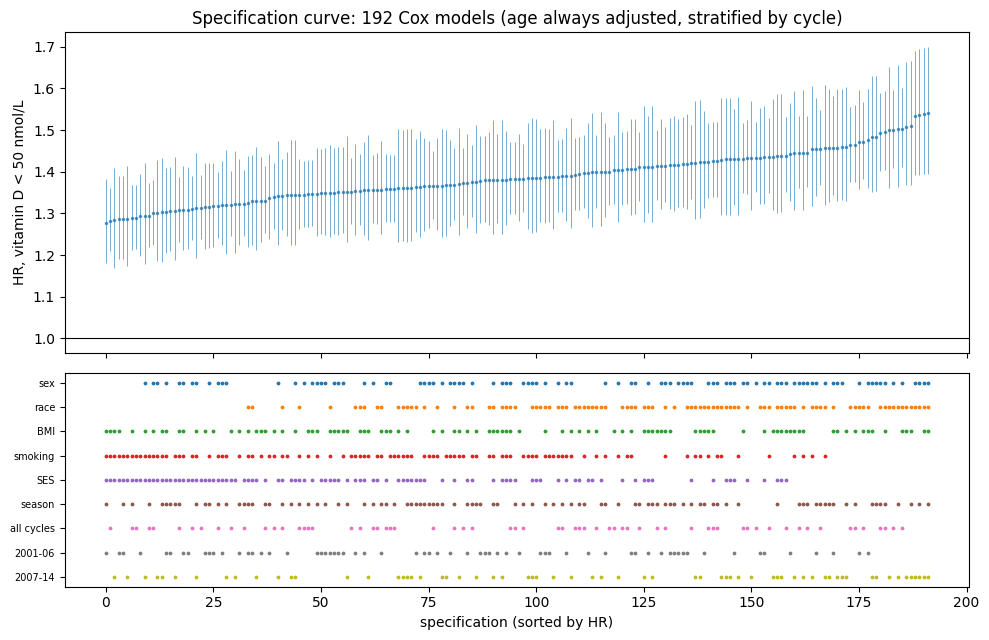

count    192.00
mean       1.39
std        0.06
min        1.28
25%        1.35
50%        1.38
75%        1.43
max        1.54

mean HR by race adjustment:
 race
0    1.36
1    1.42

mean HR by smoking adjustment:
 smoking
0    1.41
1    1.36

mean HR by sample:
 sample
2001-06       1.37
2007-14       1.40
all cycles    1.39


In [14]:
import itertools, matplotlib.pyplot as plt
groups = {"sex": "C(RIAGENDR)", "race": "C(RIDRETH1)", "BMI": "BMXBMI", "smoking": "C(smoke)",
          "SES": "C(DMDEDUC2) + INDFMPIR", "season": "C(RIDEXMON)"}
gn = list(groups)
samples = {"all cycles": d, "2001-06": d[d.cycle <= 2005], "2007-14": d[d.cycle >= 2007]}

def fit_spec(sname, mask):
    terms = ["RIDAGEYR + I(RIDAGEYR**2)"] + [groups[g] for g, m in zip(gn, mask) if m]
    x = samples[sname]
    r = PHReg.from_formula("t ~ low50 + " + " + ".join(terms), data=x, status=x.died.values, strata=x.cycle.values).fit()
    i = r.model.exog_names.index("low50"); b, se = r.params[i], r.bse[i]
    return dict(sample=sname, **{g: int(m) for g, m in zip(gn, mask)}, HR=np.exp(b), lo=np.exp(b - 1.96*se), hi=np.exp(b + 1.96*se))

specs = [(s, m) for s in samples for m in itertools.product([0, 1], repeat=len(gn))]
sc = pd.DataFrame(Parallel(n_jobs=-1)(delayed(fit_spec)(s, m) for s, m in specs))
sc.to_csv("/kaggle/working/spec_curve.csv", index=False)

sc = sc.sort_values("HR").reset_index(drop=True)
fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True, gridspec_kw={"height_ratios": [3, 2]})
a1.errorbar(sc.index, sc.HR, yerr=[sc.HR - sc.lo, sc.hi - sc.HR], fmt=".", ms=3, lw=.6, alpha=.7)
a1.axhline(1, color="k", lw=.8); a1.set_ylabel("HR, vitamin D < 50 nmol/L")
a1.set_title(f"Specification curve: {len(sc)} Cox models (age always adjusted, stratified by cycle)")
rowsl = gn + list(samples)
for k, nme in enumerate(rowsl):
    on = ((sc[nme] == 1) if nme in gn else (sc["sample"] == nme)).values
    a2.scatter(sc.index[on], [k] * on.sum(), s=3)
a2.set_yticks(range(len(rowsl))); a2.set_yticklabels(rowsl, fontsize=7); a2.invert_yaxis()
a2.set_xlabel("specification (sorted by HR)")
plt.tight_layout(); plt.savefig("/kaggle/working/fig_spec_curve.png", dpi=150); plt.show()
print(sc.HR.describe().round(2).to_string())
print("\nmean HR by race adjustment:\n", sc.groupby("race").HR.mean().round(2).to_string())
print("\nmean HR by smoking adjustment:\n", sc.groupby("smoking").HR.mean().round(2).to_string())
print("\nmean HR by sample:\n", sc.groupby("sample").HR.mean().round(2).to_string())

In [15]:
!pip install -q lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 5.1 MB/s eta 0:00:00:00:0100:01


In [16]:
import time, warnings; warnings.filterwarnings("ignore")
from lifelines import CoxPHFitter

s = d.copy()
s = s[(s.WTMEC2YR.fillna(0) > 0) & (s.t > 0)].copy()          # drops zero-weight rows and the 4 people with 0 follow-up
s["w"] = s.WTMEC2YR / s.cycle.nunique()
s["stratum"] = s.cycle.astype(int).astype(str) + "_" + s.SDMVSTRA.astype(int).astype(str)
s["psu"] = s.stratum + "_" + s.SDMVPSU.astype(int).astype(str)
nh = s.groupby("stratum").psu.nunique()
print("rows:", len(s), "| strata:", s.stratum.nunique(), "| PSUs:", s.psu.nunique(), "| strata with <2 PSUs:", int((nh < 2).sum()))

rhs = "low50 + RIDAGEYR + I(RIDAGEYR**2) + C(RIAGENDR) + C(RIDRETH1) + BMXBMI + C(smoke) + C(DMDEDUC2) + INDFMPIR + C(RIDEXMON)"
need = ["t", "died", "w", "cycle", "psu", "low50", "RIDAGEYR", "RIAGENDR", "RIDRETH1", "BMXBMI", "smoke", "DMDEDUC2", "INDFMPIR", "RIDEXMON"]
def fit(data, weights=True, robust=False, cluster=None):
    kw = dict(duration_col="t", event_col="died", strata=["cycle"], formula=rhs)
    if weights: kw["weights_col"] = "w"
    if robust: kw["robust"] = True
    if cluster: kw["cluster_col"] = cluster
    return CoxPHFitter().fit(data[need], **kw)

def show(label, m):
    r = m.summary.loc["low50"]
    print(f"{label:46s} HR {r['exp(coef)']:.2f}  [{r['exp(coef) lower 95%']:.2f}, {r['exp(coef) upper 95%']:.2f}]   SE(log HR) {r['se(coef)']:.4f}")
    return r["se(coef)"]

t0 = time.time(); m_unw = fit(s, weights=False); print("one fit took", round(time.time() - t0, 1), "s")
se_unw = show("unweighted, model-based (as before)", m_unw)
se_rob = show("weighted, PSU-clustered robust SE", fit(s, weights=True, robust=True, cluster="psu"))

rows: 31176 | strata: 105 | PSUs: 214 | strata with <2 PSUs: 0
one fit took 1.6 s
unweighted, model-based (as before)            HR 1.37  [1.29, 1.46]   SE(log HR) 0.0322
weighted, PSU-clustered robust SE              HR 1.44  [1.32, 1.58]   SE(log HR) 0.0458


In [17]:
from joblib import Parallel, delayed
from scipy import stats

beta = fit(s).params_["low50"]                           # weighted point estimate
nh_d = nh.to_dict()
pairs = [(h, p) for h, grp in s.groupby("stratum").psu for p in grp.unique()]

def rep(h, p):
    x = s[s.psu != p].copy(); m = x.stratum == h
    x.loc[m, "w"] = x.loc[m, "w"] * nh_d[h] / (nh_d[h] - 1)   # reweight the remaining PSUs of that stratum
    return h, fit(x).params_["low50"]

t0 = time.time()
res = Parallel(n_jobs=-1)(delayed(rep)(h, p) for h, p in pairs)
V = sum((nh_d[h] - 1) / nh_d[h] * (b - beta) ** 2 for h, b in res)
se_jk = np.sqrt(V); dfree = len(pairs) - len(nh_d); tc = stats.t.ppf(.975, dfree)
print(f"{len(pairs)} replicates in {time.time()-t0:.0f}s | df = {dfree}")
print(f"{'weighted, design-based (jackknife)':46s} HR {np.exp(beta):.2f}  [{np.exp(beta - tc*se_jk):.2f}, {np.exp(beta + tc*se_jk):.2f}]   SE(log HR) {se_jk:.4f}")
print(f"\nSE ratio, design-based / naive model-based: {se_jk/se_unw:.2f}  (design effect about {(se_jk/se_unw)**2:.2f})")
pd.DataFrame({"stratum": [h for h, _ in res], "beta_rep": [b for _, b in res]}).to_csv("/kaggle/working/jackknife_reps.csv", index=False)

/usr/local/lib/python3.13/dist-packages/lifelines/fitters/coxph_fitter.py:1356: StatisticalWarning: It appears your weights are not integers, possibly propensity or sampling scores then?
It's important to know that the naive variance estimates of the coefficients are biased. Instead a) set `robust=True` in the call to `fit`, or b) use Monte Carlo to
estimate the variances. See paper "Variance estimation when using inverse probability of treatment weighting (IPTW) with survival analysis"

  warnings.warn(
/usr/local/lib/python3.13/dist-packages/lifelines/fitters/coxph_fitter.py:1356: StatisticalWarning: It appears your weights are not integers, possibly propensity or sampling scores then?
It's important to know that the naive variance estimates of the coefficients are biased. Instead a) set `robust=True` in the call to `fit`, or b) use Monte Carlo to
estimate the variances. See paper "Variance estimation when using inverse probability of treatment weighting (IPTW) with survival analysis

214 replicates in 164s | df = 109
weighted, design-based (jackknife)             HR 1.44  [1.32, 1.57]   SE(log HR) 0.0435

SE ratio, design-based / naive model-based: 1.35  (design effect about 1.82)


In [18]:
hr2rr = lambda hr: (1 - 0.5**np.sqrt(hr)) / (1 - 0.5**np.sqrt(1 / hr))
ev = lambda rr: max(rr, 1/rr) + np.sqrt(max(rr, 1/rr) * (max(rr, 1/rr) - 1))
b_unw = m_unw.params_["low50"]
rows = [("unweighted, model-based", b_unw, se_unw, 1.96), ("weighted, PSU-clustered robust SE", beta, se_rob, 1.96),
        ("weighted, design-based jackknife", beta, se_jk, tc)]
for lab, b, se, c in rows:
    print(f"{lab:36s} HR {np.exp(b):.2f} [{np.exp(b-c*se):.2f}, {np.exp(b+c*se):.2f}]  SE {se:.4f}")
print("E-value (weighted HR, common-outcome approx):", round(ev(hr2rr(np.exp(beta))), 2),
      "| CI bound:", round(ev(hr2rr(np.exp(beta - tc*se_jk))), 2))

unweighted, model-based              HR 1.37 [1.29, 1.46]  SE 0.0322
weighted, PSU-clustered robust SE    HR 1.44 [1.32, 1.58]  SE 0.0458
weighted, design-based jackknife     HR 1.44 [1.32, 1.57]  SE 0.0435
E-value (weighted HR, common-outcome approx): 1.9 | CI bound: 1.72
